# GWT Ordinal Model: Initial Analysis

First proper fit of the integrated ordinal DCM on Global Workspace Theory / 2024 Leading Chat LLMs.

**Model summary:** Beta/Bernoulli hierarchy above indicators (unchanged from original DCM). At indicator leaves, expert ratings are modelled via a constrained ordered probit with latent indicator state $z_j$ marginalised analytically using the parent-implied probability $q_j$.

**Observation model:**
- Shared discrimination $a > 0$
- Expert-specific location shifts $b_e$ (anchor expert $b_0 = 0$)
- Shared ordered cutpoints $\kappa_1 < \cdots < \kappa_6$
- Latent variance fixed to 1 (probit convention)

**Caveat:** Current data are legacy probability values converted to ordinal via a temporary adapter. Native 7-point Likert data collection is in progress.

In [1]:
import sys

sys.path.insert(0, "..")

import numpy as np
import pymc as pm
import pytensor.tensor as pt
import arviz as az
import matplotlib.pyplot as plt
from scipy.stats import norm

from dcm_model import (
    ModelConfig,
    OrdinalDataProcessor,
    EvidenceProcessor,
    BayesianModelBuilder,
    ResultsManager,
    load_data,
    setup_logging,
    node_key,
    legacy_probability_to_ordinal,
)

plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "font.size": 11,
        "axes.titlesize": 12,
        "axes.labelsize": 11,
    }
)

logger = setup_logging("WARNING")
print(f"PyMC {pm.__version__}, ArviZ {az.__version__}")

/Users/ryankelly/ryan-code/research/dcm-code/.venv/lib/python3.12/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


PyMC 5.28.0, ArviZ 0.23.4


---

## 1. Data loading and preprocessing

In [2]:
config = ModelConfig(
    NUM_SAMPLES=1000,
    NUM_TUNE=1000,
    NUM_CHAINS=4,
    TARGET_ACCEPT=0.95,
    DATA_CACHE_PATH="../data_cache.json",
)

all_data = load_data(config)
stance_data = next(item for item in all_data if item["name"] == config.TARGET_STANCE)

processor = OrdinalDataProcessor(config)
processor.process(stance_data, config.TARGET_SYSTEM)

print(f"Stance:     {config.TARGET_STANCE}")
print(f"System:     {config.TARGET_SYSTEM}")
print(f"Experts:    {processor.expert_names}")
print(f"Anchor:     {processor.anchor_expert}")
print(f"Indicators: {len(processor.observations)}")
total_obs = sum(len(v) for v in processor.observations.values())
print(f"Total obs:  {total_obs}")

Stance:     Global Workspace Theory
System:     2024 Leading Chat LLMs
Experts:    ['Derek Shiller', 'Andreas Mogensen', 'Felix Binder', 'Luhan Mikaelson']
Anchor:     Derek Shiller
Indicators: 50
Total obs:  186


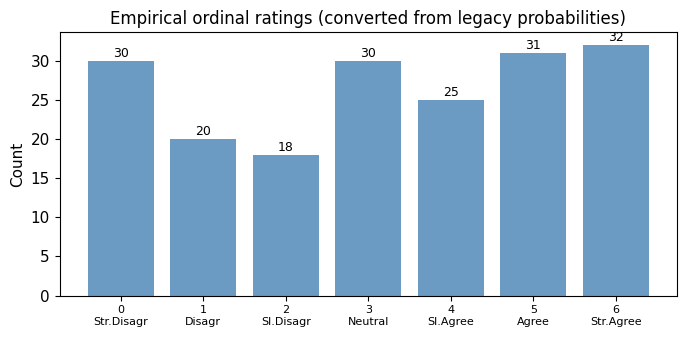

Total: 186 observations
Category counts: {0: np.int64(30), 1: np.int64(20), 2: np.int64(18), 3: np.int64(30), 4: np.int64(25), 5: np.int64(31), 6: np.int64(32)}


In [3]:
# Empirical category distribution
all_ratings = [r for obs_list in processor.observations.values() for _, r in obs_list]
all_ratings = np.array(all_ratings)

fig, ax = plt.subplots(figsize=(7, 3.5))
cat_labels = [
    "0\nStr.Disagr",
    "1\nDisagr",
    "2\nSl.Disagr",
    "3\nNeutral",
    "4\nSl.Agree",
    "5\nAgree",
    "6\nStr.Agree",
]
counts = [np.sum(all_ratings == k) for k in range(7)]
ax.bar(range(7), counts, color="steelblue", alpha=0.8)
ax.set_xticks(range(7))
ax.set_xticklabels(cat_labels, fontsize=8)
ax.set_ylabel("Count")
ax.set_title("Empirical ordinal ratings (converted from legacy probabilities)")
for i, c in enumerate(counts):
    ax.text(i, c + 0.5, str(c), ha="center", fontsize=9)
plt.tight_layout()
plt.show()

print(f"Total: {len(all_ratings)} observations")
print(f"Category counts: {dict(zip(range(7), counts))}")

---

## 2. Model build and fit

In [4]:
evidence_proc = EvidenceProcessor(config)
builder = BayesianModelBuilder(config, evidence_proc, processor)
model = builder.build_model(stance_data)

print(f"Free RVs:       {len(model.free_RVs)}")
print(f"Potentials:     {len(model.potentials)}")
print(f"Deterministics: {len(model.deterministics)}")

Free RVs:       180
Potentials:     50
Deterministics: 125


In [5]:
idata = builder.sample(model)

/Users/ryankelly/ryan-code/research/dcm-code/.venv/lib/python3.12/site-packages/pytensor/tensor/rewriting/elemwise.py:881: UserWarning: Loop fusion failed because the resulting node would exceed the kernel argument limit.
  warn(
Multiprocess sampling (4 chains in 4 jobs)
2026-03-24 09:22:15 - pymc.sampling.mcmc - INFO - Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
2026-03-24 09:22:15 - pymc.sampling.mcmc - INFO - CompoundStep
>NUTS: [global_workspace_theory_beta, a, b_free, kappa, representationality_beta_pres, representationality_beta_abs, conceptual_representations_beta_pres, conceptual_representations_beta_abs, activation_steering_effects_beta_pres, activation_steering_effects_beta_abs, probe-detectable_themes_beta_pres, probe-detectable_themes_beta_abs, concept-specific_ablation_effects_beta_pres, concept-specific_ablation_effects_beta_abs, propositional_representations_beta_pres, propositional_representations_beta_abs, logical_inference_beta_pres, logical_inference_bet

/Users/ryankelly/ryan-code/research/dcm-code/.venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 121 seconds.
2026-03-24 09:24:16 - pymc.sampling.mcmc - INFO - Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 121 seconds.


---

## 3. Convergence diagnostics

In [6]:
# Summary for key observation model parameters
obs_vars = ["a"]
if "b_free" in idata.posterior:
    obs_vars.append("b_free")
obs_vars.append("kappa")

print(az.summary(idata, var_names=obs_vars, round_to=3))

            mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
a          1.553  0.282   1.027    2.055      0.007    0.003  1872.112   
b_free[0]  0.132  0.226  -0.276    0.555      0.004    0.003  3630.619   
b_free[1]  0.271  0.214  -0.125    0.673      0.003    0.003  4059.050   
b_free[2]  0.451  0.215   0.083    0.885      0.003    0.003  4010.980   
kappa[0]  -0.418  0.236  -0.889   -0.007      0.006    0.005  1823.441   
kappa[1]   0.057  0.248  -0.383    0.516      0.007    0.006  1609.079   
kappa[2]   0.416  0.254  -0.029    0.890      0.007    0.006  1579.461   
kappa[3]   0.953  0.251   0.498    1.418      0.006    0.006  1691.359   
kappa[4]   1.410  0.246   0.966    1.864      0.005    0.005  2271.547   
kappa[5]   2.108  0.245   1.650    2.562      0.004    0.005  3326.775   

           ess_tail  r_hat  
a          3048.375  1.001  
b_free[0]  3011.688  1.000  
b_free[1]  3259.214  1.003  
b_free[2]  3235.852  1.000  
kappa[0]   1647.150  1.001  
kappa[1]   

In [7]:
# Rhat and ESS summary across all parameters
rhat_vals = az.rhat(idata)
max_rhat_var = None
max_rhat_val = 0.0
rhat_above_101 = []

for var_name in rhat_vals.data_vars:
    vals = rhat_vals[var_name].values
    flat = np.atleast_1d(vals)
    for v in flat:
        if v > max_rhat_val:
            max_rhat_val = v
            max_rhat_var = var_name
        if v > 1.01:
            rhat_above_101.append((var_name, float(v)))

print(f"Max rhat: {max_rhat_val:.4f} ({max_rhat_var})")
print(f"Parameters with rhat > 1.01: {len(rhat_above_101)}")
if rhat_above_101:
    for name, val in sorted(rhat_above_101, key=lambda x: -x[1])[:10]:
        print(f"  {name}: {val:.4f}")

# Divergences
if hasattr(idata, "sample_stats"):
    divs = idata.sample_stats["diverging"].values.sum()
    total_draws = idata.sample_stats["diverging"].values.size
    print(f"\nDivergences: {divs} / {total_draws} ({100 * divs / total_draws:.1f}%)")

Max rhat: 1.0059 (number_of_nodes_beta_pres)
Parameters with rhat > 1.01: 0

Divergences: 0 / 4000 (0.0%)


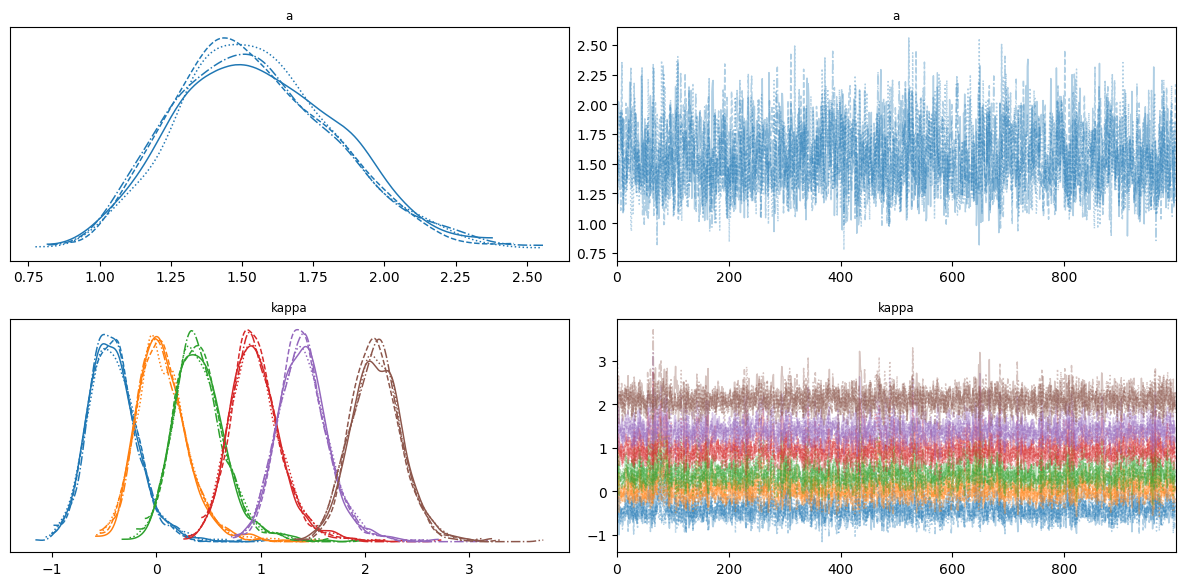

In [8]:
# Trace plots for observation model parameters
axes = az.plot_trace(
    idata,
    var_names=["a", "kappa"],
    figsize=(12, 6),
    compact=True,
)
plt.tight_layout()
plt.show()

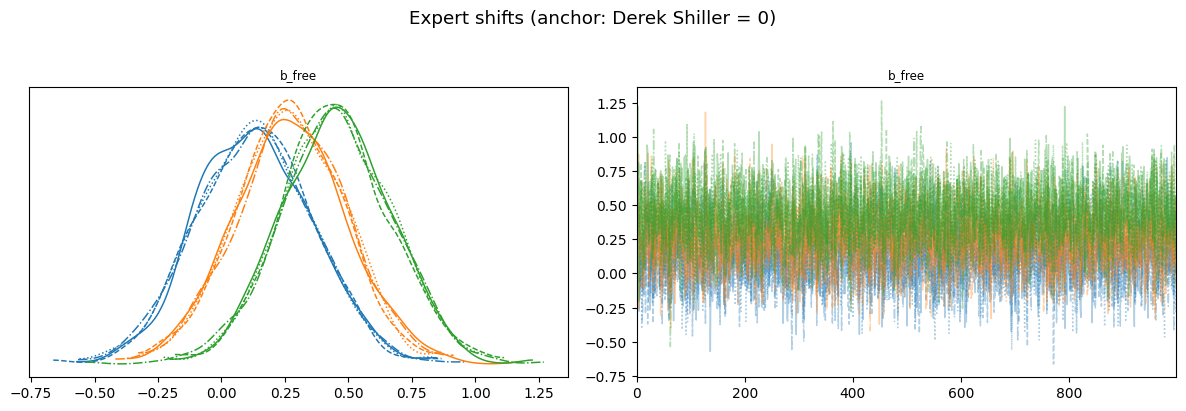

In [9]:
if "b_free" in idata.posterior:
    axes = az.plot_trace(
        idata,
        var_names=["b_free"],
        figsize=(12, 4),
        compact=True,
    )
    plt.suptitle(f"Expert shifts (anchor: {processor.anchor_expert} = 0)", y=1.02)
    plt.tight_layout()
    plt.show()

---

## 4. Observation model parameter posteriors

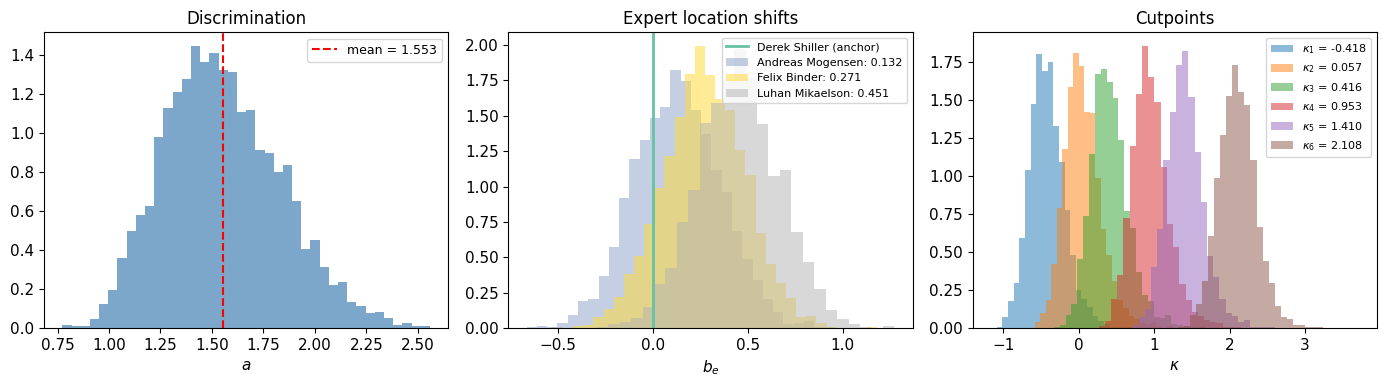

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# a (discrimination)
ax = axes[0]
a_draws = idata.posterior["a"].values.flatten()
ax.hist(a_draws, bins=40, density=True, alpha=0.7, color="steelblue")
ax.axvline(a_draws.mean(), color="red", ls="--", label=f"mean = {a_draws.mean():.3f}")
ax.set_xlabel("$a$")
ax.set_title("Discrimination")
ax.legend(fontsize=9)

# Expert shifts
ax = axes[1]
if "b_free" in idata.posterior:
    b_free_all = idata.posterior["b_free"].values  # (chain, draw, n_experts-1)
    n_free = b_free_all.shape[-1]
    colours = plt.cm.Set2(np.linspace(0, 1, n_free + 1))
    ax.axvline(
        0, color=colours[0], ls="-", lw=2, label=f"{processor.expert_names[0]} (anchor)"
    )
    for i in range(n_free):
        draws_i = b_free_all[:, :, i].flatten()
        ax.hist(
            draws_i,
            bins=30,
            density=True,
            alpha=0.5,
            color=colours[i + 1],
            label=f"{processor.expert_names[i + 1]}: {draws_i.mean():.3f}",
        )
ax.set_xlabel("$b_e$")
ax.set_title("Expert location shifts")
ax.legend(fontsize=8)

# Cutpoints
ax = axes[2]
kappa_all = idata.posterior["kappa"].values  # (chain, draw, K-1)
kappa_means = kappa_all.mean(axis=(0, 1))
for k in range(kappa_all.shape[-1]):
    draws_k = kappa_all[:, :, k].flatten()
    ax.hist(
        draws_k,
        bins=30,
        density=True,
        alpha=0.5,
        label=f"$\\kappa_{k + 1}$ = {kappa_means[k]:.3f}",
    )
ax.set_xlabel("$\\kappa$")
ax.set_title("Cutpoints")
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

---

## 5. Cutpoints on the latent scale

Visualise the recovered cutpoints as thresholds on the latent probit scale, showing the implied response distributions under $z = 0$ (indicator absent) and $z = 1$ (indicator present) for the anchor expert.

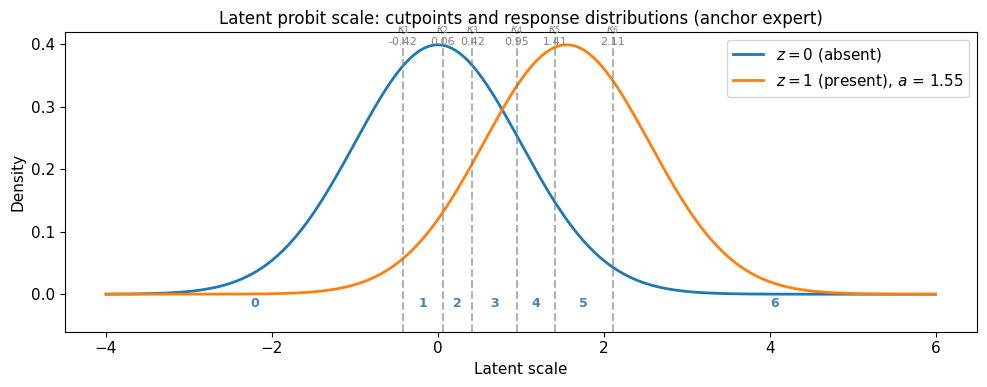

Cutpoints: ['-0.418', '0.057', '0.416', '0.953', '1.410', '2.108']
Discrimination (a): 1.553


In [11]:
a_mean = float(idata.posterior["a"].mean())
kappa_mean = idata.posterior["kappa"].mean(dim=("chain", "draw")).values

fig, ax = plt.subplots(figsize=(10, 4))

x = np.linspace(-4, 6, 500)

# Latent distribution under z=0 (anchor expert, b=0)
ax.plot(x, norm.pdf(x, loc=0), "C0", lw=2, label="$z = 0$ (absent)")
# Latent distribution under z=1
ax.plot(
    x,
    norm.pdf(x, loc=a_mean),
    "C1",
    lw=2,
    label=f"$z = 1$ (present), $a$ = {a_mean:.2f}",
)

# Cutpoints
cat_labels_short = ["0", "1", "2", "3", "4", "5", "6"]
for i, kv in enumerate(kappa_mean):
    ax.axvline(kv, color="grey", ls="--", alpha=0.6)
    ax.text(
        kv,
        ax.get_ylim()[1] * 0.95,
        f"$\\kappa_{i + 1}$\n{kv:.2f}",
        ha="center",
        fontsize=8,
        color="grey",
    )

# Category region labels
edges = [-4] + list(kappa_mean) + [6]
for i in range(len(edges) - 1):
    mid = (edges[i] + edges[i + 1]) / 2
    ax.text(
        mid,
        -0.02,
        cat_labels_short[i],
        ha="center",
        fontsize=9,
        color="steelblue",
        fontweight="bold",
    )

ax.set_xlabel("Latent scale")
ax.set_ylabel("Density")
ax.set_title(
    "Latent probit scale: cutpoints and response distributions (anchor expert)"
)
ax.legend(loc="upper right")
ax.set_ylim(bottom=-0.06)
plt.tight_layout()
plt.show()

print(f"Cutpoints: {[f'{v:.3f}' for v in kappa_mean]}")
print(f"Discrimination (a): {a_mean:.3f}")

---

## 6. Indicator-level posterior $P(z_j = 1 \mid \text{data})$

In [12]:
# Collect pz1 posteriors for all indicators
indicator_results = []

for nkey, varname in builder.node_to_varname.items():
    pz1_name = f"{varname}_pz1"
    if pz1_name in idata.posterior:
        draws = idata.posterior[pz1_name].values.flatten()
        indicator_name = nkey.split(" > ")[-1]
        parent_path = " > ".join(nkey.split(" > ")[1:-1])  # feature path
        n_obs = len(processor.observations.get(nkey, []))
        indicator_results.append(
            {
                "name": indicator_name,
                "path": parent_path,
                "mean": draws.mean(),
                "hdi_low": np.percentile(draws, 3),
                "hdi_high": np.percentile(draws, 97),
                "n_obs": n_obs,
            }
        )

indicator_results.sort(key=lambda x: -x["mean"])
print(f"Total indicators with pz1: {len(indicator_results)}")

Total indicators with pz1: 50


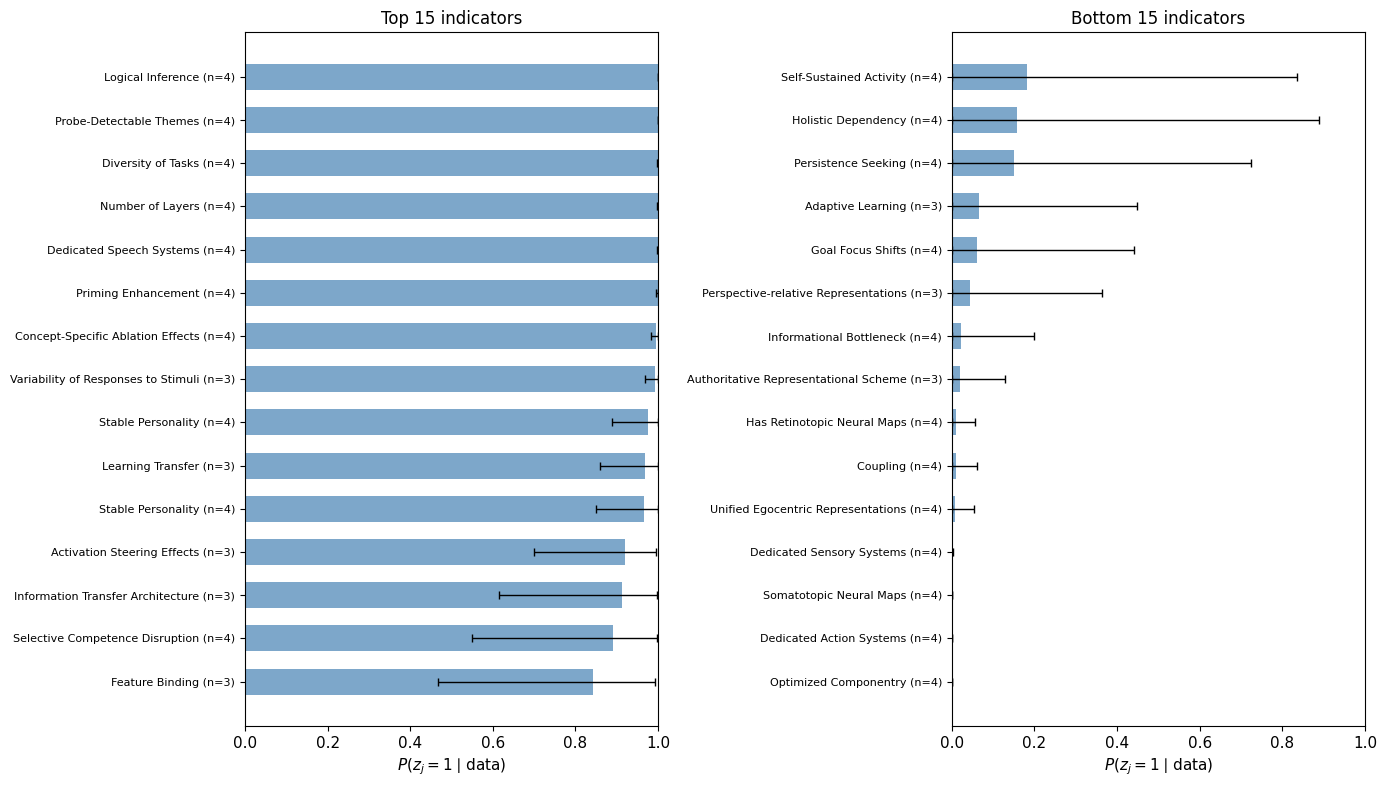

In [13]:
# Top 15 and bottom 15 indicators by posterior pz1
n_show = 15

fig, axes = plt.subplots(1, 2, figsize=(14, 8))

for ax, subset, title in [
    (axes[0], indicator_results[:n_show], f"Top {n_show} indicators"),
    (axes[1], indicator_results[-n_show:], f"Bottom {n_show} indicators"),
]:
    names = [r["name"] for r in subset]
    means = [r["mean"] for r in subset]
    lows = [r["hdi_low"] for r in subset]
    highs = [r["hdi_high"] for r in subset]
    n_obs_list = [r["n_obs"] for r in subset]

    y_pos = np.arange(len(names))
    ax.barh(y_pos, means, color="steelblue", alpha=0.7, height=0.6)
    ax.errorbar(
        means,
        y_pos,
        xerr=[np.array(means) - np.array(lows), np.array(highs) - np.array(means)],
        fmt="none",
        color="black",
        capsize=3,
        lw=1,
    )
    ax.set_yticks(y_pos)
    labels = [f"{n} (n={no})" for n, no in zip(names, n_obs_list)]
    ax.set_yticklabels(labels, fontsize=8)
    ax.set_xlabel("$P(z_j = 1 \\mid \\mathrm{data})$")
    ax.set_title(title)
    ax.set_xlim(0, 1)
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

In [14]:
# Full table
print(f"{'Indicator':<50} {'pz1':>6} {'94% HDI':>14} {'n_obs':>5}  Feature path")
print("-" * 110)
for r in indicator_results:
    print(
        f"{r['name']:<50} {r['mean']:>6.3f} "
        f"[{r['hdi_low']:.3f}, {r['hdi_high']:.3f}] "
        f"{r['n_obs']:>5}  {r['path']}"
    )

Indicator                                             pz1        94% HDI n_obs  Feature path
--------------------------------------------------------------------------------------------------------------
Logical Inference                                   1.000 [1.000, 1.000]     4  Representationality > Propositional Representations
Probe-Detectable Themes                             1.000 [0.999, 1.000]     4  Representationality > Conceptual Representations
Diversity of Tasks                                  1.000 [0.999, 1.000]     4  Complexity > Functional Diversity
Number of Layers                                    1.000 [0.999, 1.000]     4  Complexity > Structural Complexity
Dedicated Speech Systems                            1.000 [0.997, 1.000]     4  Modularity
Priming Enhancement                                 0.999 [0.995, 1.000]     4  Selective Attention > Performance Sensitivity
Concept-Specific Ablation Effects                   0.996 [0.983, 1.000]     4  Represent

---

## 7. Feature and subfeature posteriors

In [15]:
# Collect feature/subfeature Bernoulli posteriors
feature_results = []

for nkey, varname in builder.node_to_varname.items():
    bern_name = f"{varname}_bern"
    if bern_name in idata.posterior:
        draws = idata.posterior[bern_name].values.flatten()
        node_name = nkey.split(" > ")[-1]
        depth = len(nkey.split(" > ")) - 1  # 0 = stance
        feature_results.append(
            {
                "name": node_name,
                "key": nkey,
                "depth": depth,
                "mean": draws.mean(),
                "hdi_low": np.percentile(draws, 3),
                "hdi_high": np.percentile(draws, 97),
            }
        )

# Sort by tree order (depth then alphabetical)
feature_results.sort(key=lambda x: x["key"])

print(f"{'Node':<55} {'Posterior':>8} {'94% HDI':>14}  Depth")
print("-" * 90)
for r in feature_results:
    indent = "  " * r["depth"]
    print(
        f"{indent}{r['name']:<{55 - 2 * r['depth']}} {r['mean']:>8.3f} "
        f"[{r['hdi_low']:.3f}, {r['hdi_high']:.3f}]  {r['depth']}"
    )

Node                                                    Posterior        94% HDI  Depth
------------------------------------------------------------------------------------------
Global Workspace Theory                                    0.038 [0.000, 1.000]  0
  Coherence                                                0.080 [0.000, 1.000]  1
    Autonomous Subparts                                    0.527 [0.000, 1.000]  2
    Common Representational Scheme                         0.090 [0.000, 1.000]  2
    Point of View                                          0.159 [0.000, 1.000]  2
    Social Coherence                                       0.490 [0.000, 1.000]  2
  Complexity                                               0.562 [0.000, 1.000]  1
    Functional Diversity                                   0.737 [0.000, 1.000]  2
    Informational Complexity                               0.502 [0.000, 1.000]  2
      Efficient Network Topology                           0.633 [0.000, 1

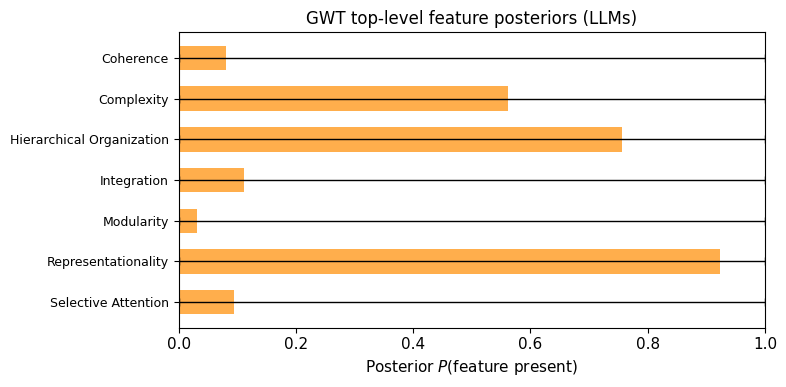

In [16]:
# Top-level features only
top_features = [r for r in feature_results if r["depth"] == 1]

fig, ax = plt.subplots(figsize=(8, 4))
names = [r["name"] for r in top_features]
means = [r["mean"] for r in top_features]
lows = [r["hdi_low"] for r in top_features]
highs = [r["hdi_high"] for r in top_features]

y_pos = np.arange(len(names))
ax.barh(y_pos, means, color="darkorange", alpha=0.7, height=0.6)
ax.errorbar(
    means,
    y_pos,
    xerr=[np.array(means) - np.array(lows), np.array(highs) - np.array(means)],
    fmt="none",
    color="black",
    capsize=3,
    lw=1,
)
ax.set_yticks(y_pos)
ax.set_yticklabels(names, fontsize=9)
ax.set_xlabel("Posterior $P(\\mathrm{feature\\ present})$")
ax.set_title("GWT top-level feature posteriors (LLMs)")
ax.set_xlim(0, 1)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

---

## 8. Manual posterior predictive check

Since the likelihood is added via `pm.Potential`, we compute posterior-implied category probabilities manually and compare against the empirical histogram.

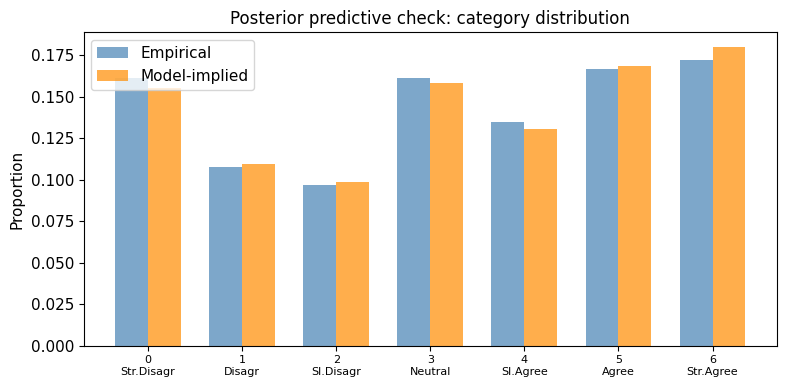

In [17]:
def compute_category_probs(kappa: np.ndarray, eta: float, K: int = 7) -> np.ndarray:
    """Ordered probit category probabilities (NumPy)."""
    c_aug = np.concatenate([[-np.inf], kappa, [np.inf]])
    return np.diff(norm.cdf(c_aug - eta))


# For each posterior draw, compute the expected category distribution
# averaged over all observations (using posterior a, b, kappa, and q_j).
# Simplified: use posterior means for a quick check.
a_mean = float(idata.posterior["a"].mean())
kappa_mean = idata.posterior["kappa"].mean(dim=("chain", "draw")).values
b_mean = np.zeros(len(processor.expert_names))
if "b_free" in idata.posterior:
    b_free_mean = idata.posterior["b_free"].mean(dim=("chain", "draw")).values
    b_mean[1:] = b_free_mean

# Collect per-indicator pz1 posterior means
pz1_by_key = {}
for nkey, varname in builder.node_to_varname.items():
    pz1_name = f"{varname}_pz1"
    if pz1_name in idata.posterior:
        pz1_by_key[nkey] = float(idata.posterior[pz1_name].mean())

# Compute model-implied category probabilities for each observation
model_cat_probs = np.zeros(7)
n_total = 0

for nkey, obs_list in processor.observations.items():
    pz1 = pz1_by_key.get(nkey, 0.5)
    for expert_idx, rating in obs_list:
        probs_z0 = compute_category_probs(kappa_mean, eta=b_mean[expert_idx])
        probs_z1 = compute_category_probs(kappa_mean, eta=b_mean[expert_idx] + a_mean)
        probs_mix = (1 - pz1) * probs_z0 + pz1 * probs_z1
        model_cat_probs += probs_mix
        n_total += 1

model_cat_probs /= n_total  # average

# Empirical proportions
empirical_props = np.array(counts) / len(all_ratings)

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(7)
w = 0.35
ax.bar(x - w / 2, empirical_props, w, label="Empirical", color="steelblue", alpha=0.7)
ax.bar(
    x + w / 2, model_cat_probs, w, label="Model-implied", color="darkorange", alpha=0.7
)
ax.set_xticks(x)
ax.set_xticklabels(cat_labels, fontsize=8)
ax.set_ylabel("Proportion")
ax.set_title("Posterior predictive check: category distribution")
ax.legend()
plt.tight_layout()
plt.show()

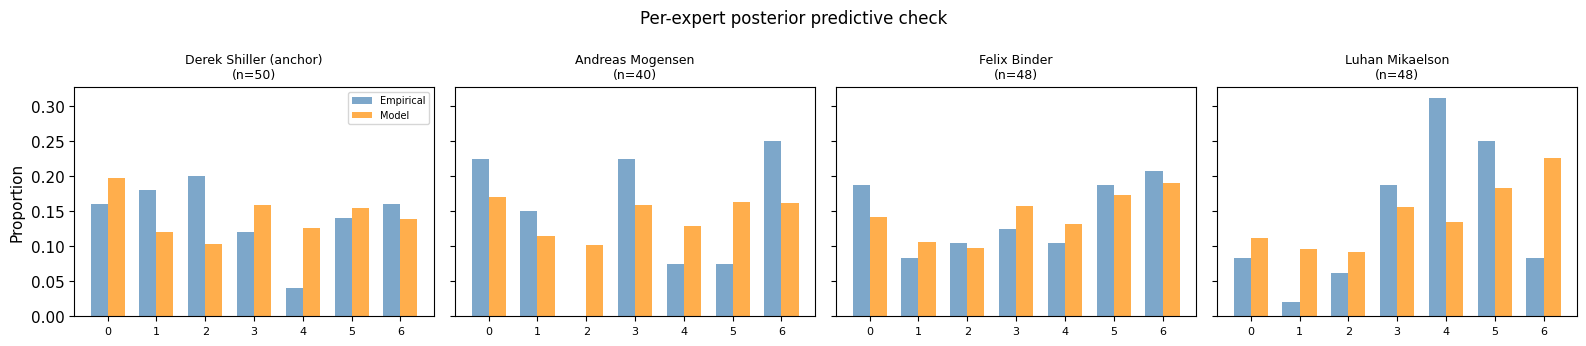

In [18]:
# Per-expert PPC breakdown
n_experts = len(processor.expert_names)
fig, axes = plt.subplots(1, n_experts, figsize=(4 * n_experts, 3.5), sharey=True)
if n_experts == 1:
    axes = [axes]

for e_idx, (ax, ename) in enumerate(zip(axes, processor.expert_names)):
    # Empirical for this expert
    expert_ratings = [
        r
        for obs_list in processor.observations.values()
        for eidx, r in obs_list
        if eidx == e_idx
    ]
    if not expert_ratings:
        continue
    emp = np.array([sum(1 for r in expert_ratings if r == k) for k in range(7)])
    emp_prop = emp / emp.sum()

    # Model-implied for this expert
    mod = np.zeros(7)
    n_e = 0
    for nkey, obs_list in processor.observations.items():
        pz1 = pz1_by_key.get(nkey, 0.5)
        for eidx, rating in obs_list:
            if eidx == e_idx:
                probs_z0 = compute_category_probs(kappa_mean, eta=b_mean[e_idx])
                probs_z1 = compute_category_probs(
                    kappa_mean, eta=b_mean[e_idx] + a_mean
                )
                mod += (1 - pz1) * probs_z0 + pz1 * probs_z1
                n_e += 1
    mod_prop = mod / n_e if n_e > 0 else mod

    x = np.arange(7)
    ax.bar(x - w / 2, emp_prop, w, color="steelblue", alpha=0.7, label="Empirical")
    ax.bar(x + w / 2, mod_prop, w, color="darkorange", alpha=0.7, label="Model")
    ax.set_xticks(x)
    ax.set_xticklabels([str(k) for k in range(7)], fontsize=8)
    suffix = " (anchor)" if e_idx == 0 else ""
    ax.set_title(f"{ename}{suffix}\n(n={len(expert_ratings)})", fontsize=9)
    if e_idx == 0:
        ax.set_ylabel("Proportion")
        ax.legend(fontsize=7)

plt.suptitle("Per-expert posterior predictive check", fontsize=12)
plt.tight_layout()
plt.show()

---

## 9. Summary

**Key outputs for communication:**
- Observation model: discrimination $a$, expert shifts $b_e$, cutpoints $\kappa$
- Per-indicator posterior $P(z_j = 1 \mid \text{data})$
- Feature-level posteriors
- Manual PPC for sanity checking

**Caveats:**
- Data are converted from legacy probability format; native Likert collection in progress
- GWT stance only
- Shared $a$ and $\kappa$ across all indicators
- No rigorous sensitivity analysis yet

**Next steps:**
- Finalise 7-point survey format with team
- Ordinalisation bin sensitivity check
- Compare against legacy binary model
- Multi-system runs (Human, ELIZA, Chicken)

In [19]:
# Print compact result package
print("=" * 60)
print("GWT Ordinal DCM -- Result Summary")
print(f"System: {config.TARGET_SYSTEM}")
print(
    f"Experts: {len(processor.expert_names)}, "
    f"Indicators: {len(indicator_results)}, "
    f"Observations: {total_obs}"
)
print(f"Anchor: {processor.anchor_expert}")
print("=" * 60)

print(f"\n  a (discrimination): {a_mean:.3f}")
print(f"  kappa (cutpoints):  {[f'{v:.3f}' for v in kappa_mean]}")
print(f"  Expert shifts:")
for i, ename in enumerate(processor.expert_names):
    tag = " (anchor)" if i == 0 else ""
    print(f"    {ename}{tag}: {b_mean[i]:.3f}")

print(
    f"\n  Stance posterior: {feature_results[0]['mean']:.3f} "
    f"[{feature_results[0]['hdi_low']:.3f}, {feature_results[0]['hdi_high']:.3f}]"
)

print(f"\n  Top 10 indicators by P(present):")
for r in indicator_results[:10]:
    print(f"    {r['mean']:.3f}  {r['name']}")

print(f"\n  Bottom 10 indicators by P(present):")
for r in indicator_results[-10:]:
    print(f"    {r['mean']:.3f}  {r['name']}")

GWT Ordinal DCM -- Result Summary
System: 2024 Leading Chat LLMs
Experts: 4, Indicators: 50, Observations: 186
Anchor: Derek Shiller

  a (discrimination): 1.553
  kappa (cutpoints):  ['-0.418', '0.057', '0.416', '0.953', '1.410', '2.108']
  Expert shifts:
    Derek Shiller (anchor): 0.000
    Andreas Mogensen: 0.132
    Felix Binder: 0.271
    Luhan Mikaelson: 0.451

  Stance posterior: 0.038 [0.000, 1.000]

  Top 10 indicators by P(present):
    1.000  Logical Inference
    1.000  Probe-Detectable Themes
    1.000  Diversity of Tasks
    1.000  Number of Layers
    1.000  Dedicated Speech Systems
    0.999  Priming Enhancement
    0.996  Concept-Specific Ablation Effects
    0.992  Variability of Responses to Stimuli
    0.977  Stable Personality
    0.968  Learning Transfer

  Bottom 10 indicators by P(present):
    0.044  Perspective-relative Representations
    0.023  Informational Bottleneck
    0.020  Authoritative Representational Scheme
    0.010  Has Retinotopic Neural Maps
 